In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.5.1+cu121
True
12.1
GPU: NVIDIA GeForce RTX 2050


In [ ]:
import cv2
from pathlib import Path

base_dir = Path(r"C:\NNDL Lab Proj\KTH")
dataset_path = base_dir / "Dataset" if (base_dir / "Dataset").exists() else base_dir
video_path = dataset_path / "walking" / "person01_walking_d1_uncomp.avi"
cap = cv2.VideoCapture(str(video_path))

print("Video opened:", cap.isOpened())
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS:", fps)
print("Frame count:", frame_count)
print("Resolution:", width, "x", height)
cap.release()

Video opened: True
FPS: 25.0
Frame count: 555
Resolution: 160 x 120


In [5]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

print("Frame successfully read:", ret)
print("Frame shape:", frame.shape)

cap.release()

Frame successfully read: True
Frame shape: (120, 160, 3)


In [7]:
import numpy as np
cap = cv2.VideoCapture(video_path)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

sample_indices = np.linspace(
    0,
    frame_count - 1,
    16,
    dtype=int
)

print(sample_indices)

[  0  36  73 110 147 184 221 258 295 332 369 406 443 480 517 554]


In [8]:
frames = []

for index in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, index)
    ret, frame = cap.read()

    if ret:
        frames.append(frame)

cap.release()

print("Number of sampled frames:", len(frames))
print("Shape of one frame:", frames[0].shape)

Number of sampled frames: 16
Shape of one frame: (120, 160, 3)


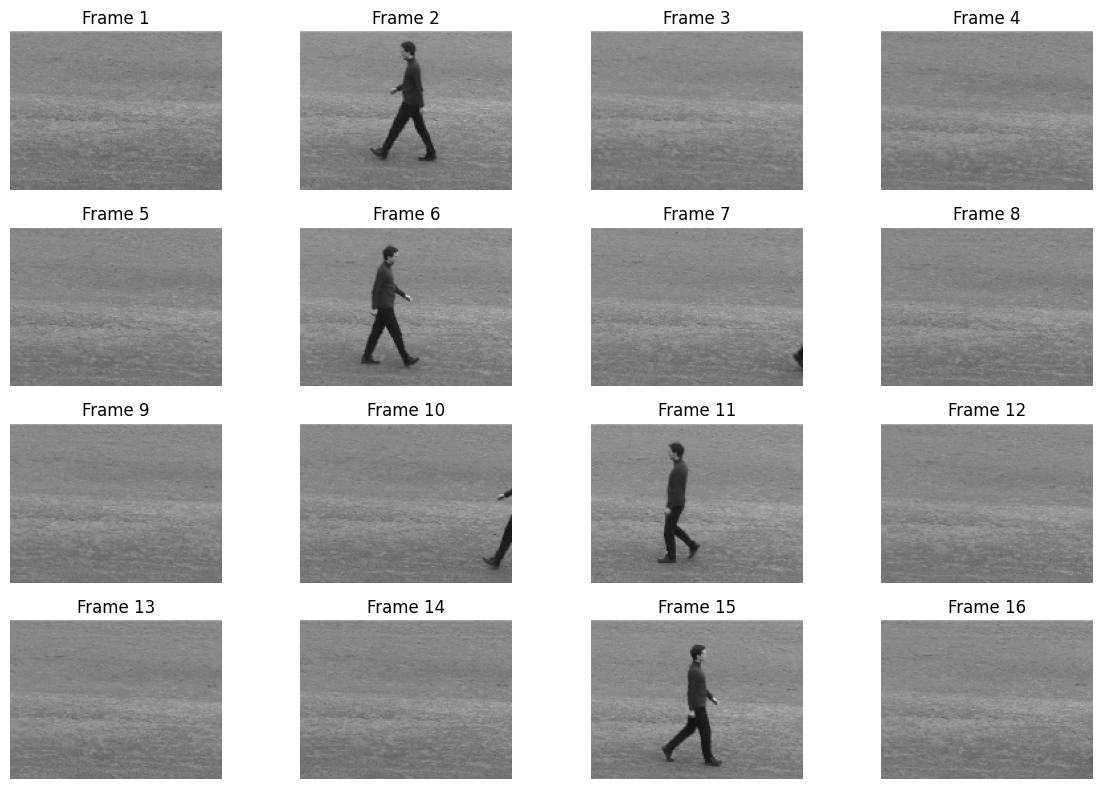

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))

for i, frame in enumerate(frames):
    plt.subplot(4, 4, i + 1)

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.imshow(frame_rgb)
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()